In [3]:
import numpy as np 
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report, f1_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

random_state = 42

In [4]:
data_path = './data/german.data-numeric'
credit = np.genfromtxt(data_path)
print(credit)
X,y = credit[:,:-1],credit[:,-1]
print(X.shape,y.shape)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

[[ 1.  6.  4. ...  0.  1.  1.]
 [ 2. 48.  2. ...  0.  1.  2.]
 [ 4. 12.  4. ...  1.  0.  1.]
 ...
 [ 4. 12.  2. ...  0.  1.  1.]
 [ 1. 45.  2. ...  0.  1.  2.]
 [ 2. 45.  4. ...  0.  1.  1.]]
(1000, 24) (1000,)
(800, 24) (800,)
(200, 24) (200,)


In [5]:
DT = DecisionTreeClassifier(random_state = random_state)
RF = RandomForestClassifier(random_state = random_state)


In [6]:
print('Demo of DT and RF prediction')
DT.fit(X_train,y_train)
RF.fit(X_train,y_train)
y_pred_DT = DT.predict(X_test)
y_pred_RF = RF.predict(X_test)

print('DT accuracy: ',accuracy_score(y_test,y_pred_DT))
print('RF accuracy: ',accuracy_score(y_test,y_pred_RF))

Demo of DT and RF prediction
DT accuracy:  0.665
RF accuracy:  0.81


In [7]:
RF.fit(X_train, y_train)
y_rf_pred = RF.predict(X_test)
print("-RF acc = {}".format(accuracy_score(y_test, y_rf_pred)))
print("-RF f1 = {}".format(f1_score(y_test, y_rf_pred)))
print("-RF roc auc = {}".format(roc_auc_score(y_test, y_rf_pred)))
print(confusion_matrix(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred))

-RF acc = 0.81
-RF f1 = 0.875
-RF roc auc = 0.7173939175381656
[[133   8]
 [ 30  29]]
              precision    recall  f1-score   support

         1.0       0.82      0.94      0.88       141
         2.0       0.78      0.49      0.60        59

    accuracy                           0.81       200
   macro avg       0.80      0.72      0.74       200
weighted avg       0.81      0.81      0.80       200



In [8]:
def grid_search(algorithm, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier()
    if algorithm == 'random-forest':
        model = RandomForestClassifier()

    
    classifier = GridSearchCV(estimator = model, param_grid=dict_param, n_jobs=n_jobs)
    classifier.fit(X_train, y_train)
    print('Best model: ', end = '')
    print(classifier.best_estimator_)
    # print('Best params: ', end = '')
    # print(classifier.best_params_)
    # print('Best score: ', end = '')
    # print(classifier.best_score_)
    return classifier.best_estimator_

def evaluate(model):
    print("Model: ", model)
    print("Trainning test: ")
    print("Train Accuracy :", accuracy_score(y_train, model.predict(X_train)))
    print("Train f1 score :", f1_score(y_train, model.predict(X_train)))
    print("Train roc auc :", roc_auc_score(y_train, model.predict(X_train)))
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-"*50)
    print("Testing test: ")
    print("Test Accuracy :", accuracy_score(y_test, model.predict(X_test)))
    print("Test f1 score :", f1_score(y_test, model.predict(X_test)))
    print("Test roc auc :", roc_auc_score(y_test, model.predict(X_test)))
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))

def plot_learning_curve(estimator, title, label_curve, X, y, ylim=None, cv=None,n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5),new_plot=False,idx_color=0):
    # Khởi tạo bức ảnh mới với thư viện plot lib
    if new_plot:
        # plt.figure()
        plt.title(title)
        plt.xlabel("Training examples")
        plt.ylabel("Score")
        plt.grid()
    # chú thích nếu có
    if ylim is not None:
        plt.ylim(*ylim)

    # thực hiện training model, ghi nhận các giá trị trong quá trình training
    # cv = số fold cross validate, số phần bộ dữ liệu được chia để thực hiện training testing.
    # train_sizes = mảng tỉ lệ, các tỉ lệ được hệ thống chọn làm điểm dừng để thực hiện 1 testing
    # train_sizes = [0.3, 0.5] => hệ thống lấy 30 % dữ liệu để train và thực hiện test, tương tự 50 % ..
    # scoring = hàm mục tiêu để đánh giá chất lượng mô hình và vẽ lên đồ thị
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,scoring="f1")
    # Lấy trung bình cộng các giá trị output của các fold
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    # thực hiện vẽ các giá trị số lên đồ thị với màu vừa được random
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std, alpha=0.1, color='g')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='r',
    label=label_curve['test'])
    plt.plot(train_sizes, train_scores_mean, 'o-', color='g',
    label=label_curve['train'])
    plt.legend(loc="best")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    return plt


Text(0.5, 1.0, 'DT validation curve for max_depth')

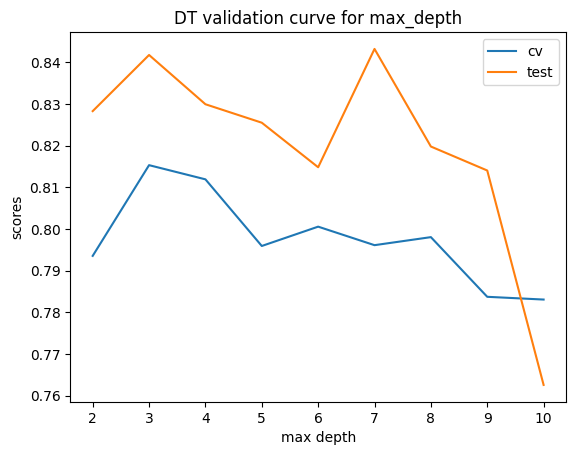

In [9]:
# Trước hết, hãy thử khảo sát DT với tham số max_depth
cv_accuracies_by_depth, test_accuracies_by_depth= [], []
max_depth_values= np.arange(2,11)
for curr_max_depth in max_depth_values:
    tree= DecisionTreeClassifier(random_state=random_state,max_depth=curr_max_depth)
    # cross-validation
    val_scores= cross_val_score(estimator=tree, X=X_train, y=y_train, cv=5,scoring='f1')
    cv_accuracies_by_depth.append(val_scores.mean())
    # test
    tree.fit(X_train, y_train)
    curr_pred= tree.predict(X_test)
    test_accuracies_by_depth.append(f1_score(curr_pred, y_test))
# Plot
plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')


In [10]:
 # Thử sử dụng GridSearchCV để khảo sát
dict_param = {
'max_depth': [2, 3, 5, 7, 10, 20],
'min_samples_leaf': [5, 10, 20, 50, 100],
'criterion': ["gini", "entropy"]
}
best_tree = grid_search('decision-tree', n_jobs=-1, dict_param=dict_param)


Best model: DecisionTreeClassifier(max_depth=5, min_samples_leaf=20)


Model:  DecisionTreeClassifier(max_depth=5, min_samples_leaf=20)
Trainning test: 
Train Accuracy : 0.77125
Train f1 score : 0.8473728106755629


Train roc auc : 0.680523905314024
Train Confusion Matrix:
[[508  51]
 [132 109]]
--------------------------------------------------
Testing test: 
Test Accuracy : 0.78
Test f1 score : 0.8533333333333334
Test roc auc : 0.6911888448130785
Test Confusion Matrix:
[[128  13]
 [ 31  28]]


<module 'matplotlib.pyplot' from 'C:\\Users\\ADMIN\\AppData\\Roaming\\Python\\Python310\\site-packages\\matplotlib\\pyplot.py'>

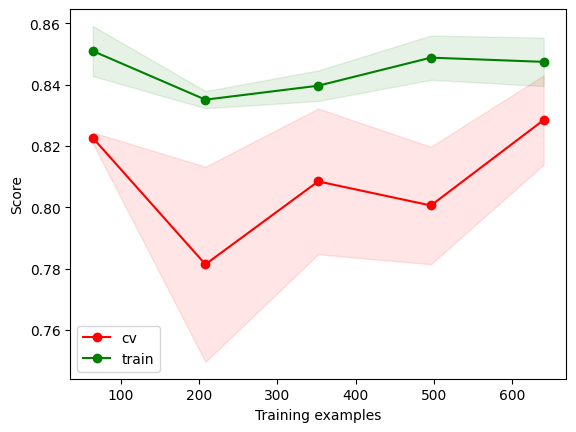

In [11]:
best_tree.fit(X_train, y_train)
evaluate(best_tree)
title = 'Learning curve with best tree'
label_curve = {'train': 'train', 'test':'cv'}
plot_learning_curve(best_tree, title, label_curve, X_train, y_train, cv=5)


Top 10 feature importances
Feature  0 - 0.40445005922715943
Feature  1 - 0.17066428015343657
Feature  2 - 0.14261352910286315
Feature  3 - 0.07120344185816782
Feature  4 - 0.05428847945598893
Feature  5 - 0.05400258515142507
Feature  6 - 0.04007488290946428
Feature  7 - 0.03813781829612112
Feature  8 - 0.015091674891623292
Feature  9 - 0.009473248953750433


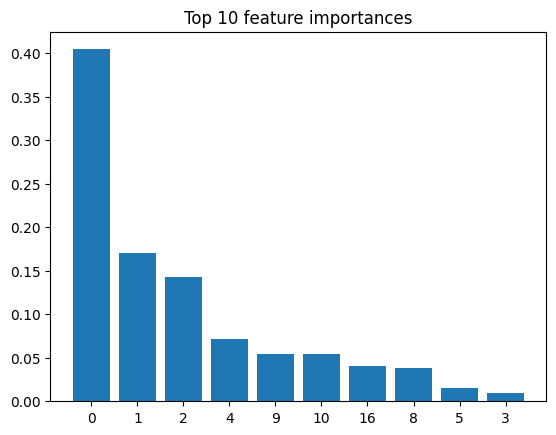

In [12]:
# Nhận xét về độ quan trọng của từng feature
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]
print('Top 10 feature importances')
for i in range(10):
    print('Feature ', i, '-', importances[indices[i]])
indices = indices[:10]
plt.figure()
plt.title('Top 10 feature importances')
plt.bar(range(10), importances[indices])
plt.xticks(range(10), indices)
plt.show()



Random Forest 


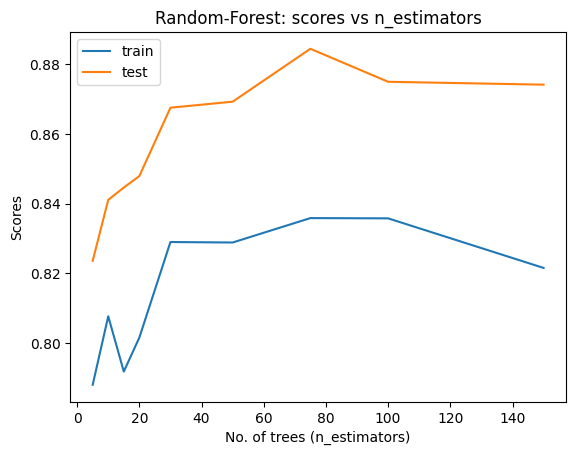

In [13]:
num_trees = [5, 10, 15, 20, 30, 50, 75, 100, 150]
train_acc = []
test_acc = []
for ntrees in num_trees:
    rf = RandomForestClassifier(n_estimators=ntrees, random_state=random_state, n_jobs=-1).fit(X_train, y_train)
    temp_train_acc=cross_val_score(rf, X_test, y_test, cv=5, scoring='f1')
    train_acc.append(temp_train_acc.mean())
    test_acc.append(f1_score(rf.predict(X_test), y_test))
plt.plot(num_trees, train_acc, label='train')
plt.plot(num_trees, test_acc, label='test')
plt.legend()
plt.xlabel('No. of trees (n_estimators)')
plt.ylabel('Scores')
plt.title('Random-Forest: scores vs n_estimators');


In [14]:
# Sử dụng GridSearch CV
dict_param = {
'max_depth': [3, 11, 15, 24, 27],
'min_samples_leaf': [1, 5, 7, 9, 15, 24],
'max_features': [4, 6, 10, 16],
'n_estimators': [75]
}

best_forest = grid_search('random-forest', n_jobs=-1, dict_param=dict_param)

Best model: RandomForestClassifier(max_depth=15, max_features=16, min_samples_leaf=5,
                       n_estimators=75)


Model:  RandomForestClassifier(max_depth=15, max_features=16, min_samples_leaf=5,
                       n_estimators=75)
Trainning test: 
Train Accuracy : 0.9
Train f1 score : 0.9318568994889267
Train roc auc : 0.8481877092318084
Train Confusion Matrix:
[[547  12]
 [ 68 173]]
--------------------------------------------------
Testing test: 
Test Accuracy : 0.795
Test f1 score : 0.8637873754152824
Test roc auc : 0.7067556196658252
Test Confusion Matrix:
[[130  11]
 [ 30  29]]


<module 'matplotlib.pyplot' from 'C:\\Users\\ADMIN\\AppData\\Roaming\\Python\\Python310\\site-packages\\matplotlib\\pyplot.py'>

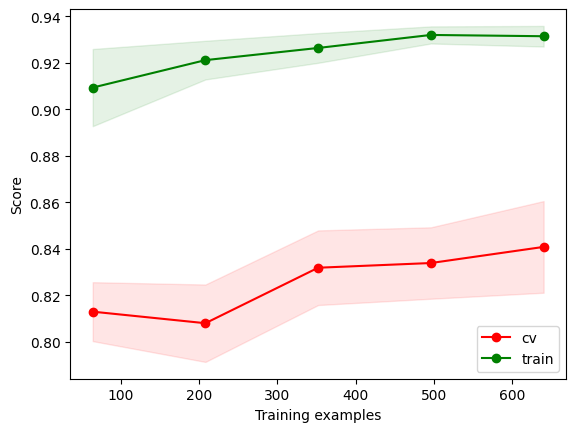

In [15]:
evaluate(best_forest)
title = 'Learning curve with best forest'
label_curve = {'train': 'train', 'test':'cv'}
plot_learning_curve(best_forest, title, label_curve, X_train, y_train, cv=5)

Top 10 feature importances
Feature  0 - 0.17891952004443584
Feature  1 - 0.14796018139063938
Feature  2 - 0.11772137174107397
Feature  3 - 0.10913321263071282
Feature  4 - 0.0792427605128825
Feature  5 - 0.04735787064648834
Feature  6 - 0.04526728519142635
Feature  7 - 0.043101041638165694
Feature  8 - 0.03850372353857324
Feature  9 - 0.032657265832887104


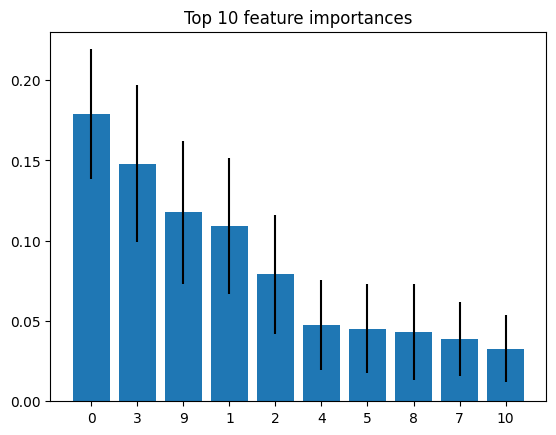

In [17]:
# Giải: Feature importance
best_forest.fit(X_train,y_train)
importances = best_forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in best_forest.estimators_], axis=0)
indices = np.argsort(importances)[::-1]
print('Top 10 feature importances')
for i in range(10):
    print('Feature ', i, '-', importances[indices[i]])
indices = indices[:10]
plt.figure()
plt.title('Top 10 feature importances')
plt.bar(range(10), importances[indices], yerr=std[indices])
plt.xticks(range(10), indices)
plt.show()


In [18]:
# Thử bỏ một sô feature có độ quan trọng thấp đi
# Chú ý tham max_features cần thay đổi
sfm = SelectFromModel(best_forest, threshold='mean')
sfm.fit(X_train, y_train)
X_train_dropped = sfm.transform(X_train)
X_test_dropped = sfm.transform(X_test)
title = 'Learning with dropped features'
label_curve = {'train': 'train', 'test':'cv'}
forest_dropped = RandomForestClassifier(max_depth=11, min_samples_leaf=5,
n_estimators=75, n_jobs=-1, random_state=random_state)
# plot_learning_curve(forest_dropped, title, label_curve, X_train_dropped,y_train, cv=5)
forest_dropped.fit(X_train_dropped, y_train)
y_dropped_pred = forest_dropped.predict(X_test_dropped)
print('acc', accuracy_score(y_test, y_dropped_pred))
print('f1', f1_score(y_test, y_dropped_pred))
print('roc_auc', roc_auc_score(y_test, y_dropped_pred))

acc 0.785
f1 0.8599348534201955
roc_auc 0.6799495131626397
